In [7]:
!pip install timm

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# ============================================================
# Unzip Split Dataset to Runtime + Audit Train/Val/Test
# ============================================================

import os
import zipfile
import shutil
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ------------------------------------------------------------
# 1. Configure paths
# ------------------------------------------------------------

# Change this if your zip file has a different input path/name.
ZIP_PATH = "/content/drive/MyDrive/Transformer/splitted_dataset.zip"

# Runtime output location
RUNTIME_DIR = Path("working")
EXTRACT_DIR = RUNTIME_DIR / "splitted_dataset_extracted"

# Final dataset root expected by training code
FINAL_DATASET_DIR = RUNTIME_DIR / "splitted_dataset"

# Keep class order consistent with your training label mapping:
# Attentive = 0, Sleepy = 1, Distracted = 2
TARGET_CLASSES = ["Attentive", "Sleepy", "Distracted"]
SPLITS = ["train", "val", "test"]


# ------------------------------------------------------------
# 2. Unzip dataset
# ------------------------------------------------------------

def unzip_dataset(zip_path, extract_dir, final_dataset_dir):
    zip_path = Path(zip_path)

    if not zip_path.exists():
        raise FileNotFoundError(
            f"Zip file not found: {zip_path}\n"
            "Update ZIP_PATH to match your input dataset path."
        )

    # Clean previous extraction if rerunning notebook
    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 50)
    print("UNZIPPING SPLIT DATASET")
    print("=" * 50)
    print(f"Zip file: {zip_path}")
    print(f"Extracting to: {extract_dir}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    print("Unzip complete.")

    # Try to locate the actual dataset root.
    # Handles both:
    # extracted/train/...
    # extracted/splitted_dataset/train/...
    candidate_roots = []

    if all((extract_dir / split).exists() for split in SPLITS):
        candidate_roots.append(extract_dir)

    for child in extract_dir.iterdir():
        if child.is_dir() and all((child / split).exists() for split in SPLITS):
            candidate_roots.append(child)

    if not candidate_roots:
        raise RuntimeError(
            "Could not find a valid split dataset root containing train/val/test folders."
        )

    detected_root = candidate_roots[0]
    print(f"Detected dataset root: {detected_root}")

    # Copy/move to the standard path used by your training code
    if final_dataset_dir.exists():
        shutil.rmtree(final_dataset_dir)

    shutil.copytree(detected_root, final_dataset_dir)

    print(f"Dataset ready at: {final_dataset_dir}")
    print("=" * 50)

    return final_dataset_dir


DATASET_DIR = unzip_dataset(
    ZIP_PATH,
    EXTRACT_DIR,
    FINAL_DATASET_DIR
)

UNZIPPING SPLIT DATASET
Zip file: /content/drive/MyDrive/Transformer/splitted_dataset.zip
Extracting to: working/splitted_dataset_extracted
Unzip complete.
Detected dataset root: working/splitted_dataset_extracted/splitted_dataset
Dataset ready at: working/splitted_dataset


# Dataset Audit

STARTING DATASET AUDIT: TRAIN

Summary Statistics:
   Total files scanned: 2994
   Total valid images: 2994
   Attentive: 1179 valid images (39.38%)
   Sleepy: 1025 valid images (34.24%)
   Distracted: 790 valid images (26.39%)

File Extension Distribution:
   .jpg: 2994 files

Integrity Check:
   No corrupt images found.


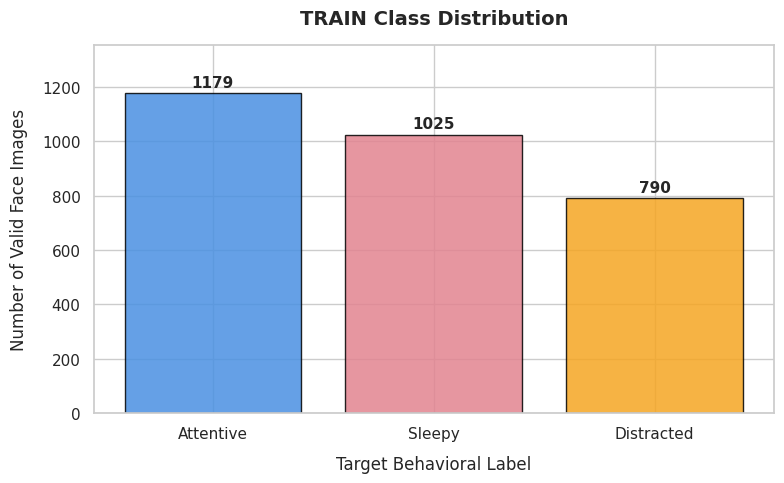

AUDIT FINISHED: TRAIN
STARTING DATASET AUDIT: VAL

Summary Statistics:
   Total files scanned: 374
   Total valid images: 374
   Attentive: 147 valid images (39.30%)
   Sleepy: 128 valid images (34.22%)
   Distracted: 99 valid images (26.47%)

File Extension Distribution:
   .jpg: 374 files

Integrity Check:
   No corrupt images found.


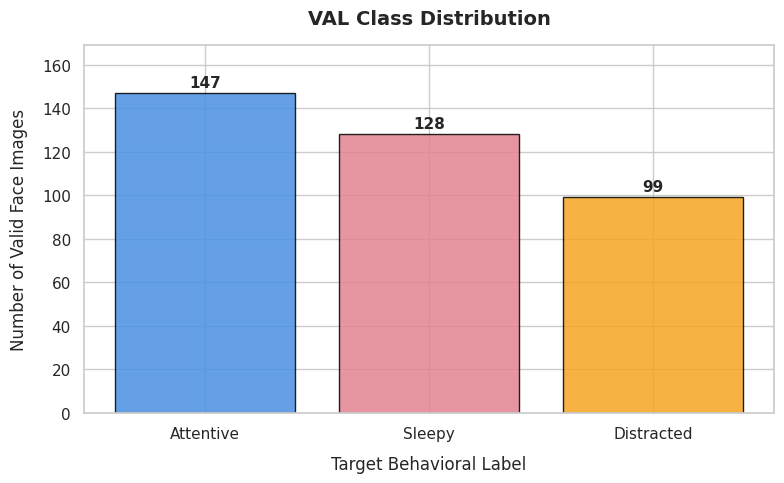

AUDIT FINISHED: VAL
STARTING DATASET AUDIT: TEST

Summary Statistics:
   Total files scanned: 375
   Total valid images: 375
   Attentive: 148 valid images (39.47%)
   Sleepy: 129 valid images (34.40%)
   Distracted: 98 valid images (26.13%)

File Extension Distribution:
   .jpg: 375 files

Integrity Check:
   No corrupt images found.


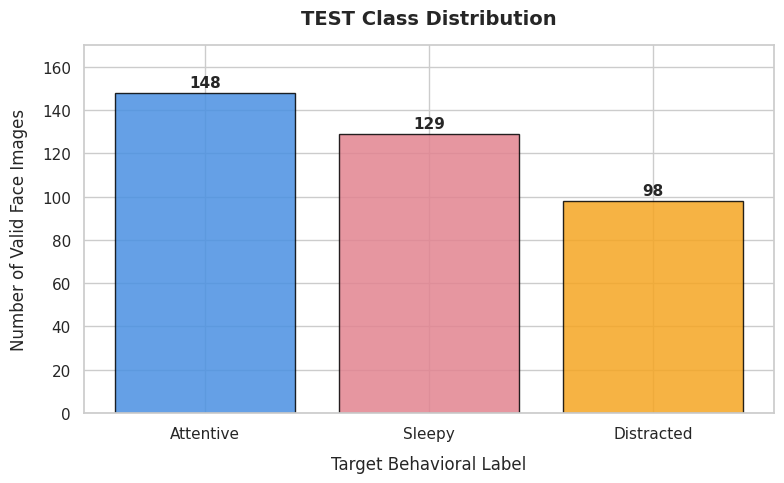

AUDIT FINISHED: TEST


In [4]:
# ============================================================
# Audit Split Dataset
# ============================================================

def audit_single_split(split_path, split_name):
    print("=" * 50)
    print(f"STARTING DATASET AUDIT: {split_name.upper()}")
    print("=" * 50)

    path = Path(split_path)

    class_counts = {}
    extension_counts = Counter()
    total_files = 0
    valid_images = 0
    corrupt_files = []

    for cls in TARGET_CLASSES:
        class_dir = path / cls

        if not class_dir.exists():
            print(f"Warning: Class folder {cls!r} not found in {split_path}")
            class_counts[cls] = 0
            continue

        images_in_class = 0

        for img_file in class_dir.iterdir():
            if img_file.is_file():
                total_files += 1
                ext = img_file.suffix.lower()
                extension_counts[ext] += 1

                try:
                    with Image.open(img_file) as img:
                        img.verify()

                    images_in_class += 1
                    valid_images += 1

                except Exception:
                    corrupt_files.append(str(img_file.relative_to(path)))

        class_counts[cls] = images_in_class

    print("\nSummary Statistics:")
    print(f"   Total files scanned: {total_files}")
    print(f"   Total valid images: {valid_images}")

    for cls, count in class_counts.items():
        pct = (count / valid_images * 100) if valid_images > 0 else 0
        print(f"   {cls}: {count} valid images ({pct:.2f}%)")

    print("\nFile Extension Distribution:")
    for ext, count in extension_counts.items():
        print(f"   {ext or 'no extension'}: {count} files")

    print("\nIntegrity Check:")
    if corrupt_files:
        print(f"   Found {len(corrupt_files)} CORRUPT/UNREADABLE images!")
        print(f"   First few: {corrupt_files[:5]}")
    else:
        print("   No corrupt images found.")

    # Plot class distribution
    plt.figure(figsize=(8, 5))
    sns.set_theme(style="whitegrid")

    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    colors = ["#4A90E2", "#E28490", "#F5A623"]

    bars = plt.bar(
        classes,
        counts,
        color=colors,
        edgecolor="black",
        alpha=0.85
    )

    max_count = max(counts) if counts else 0

    for bar in bars:
        yval = bar.get_height()
        offset = max_count * 0.01 if max_count > 0 else 1
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            yval + offset,
            f"{int(yval)}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=11
        )

    plt.title(
        f"{split_name.upper()} Class Distribution",
        fontsize=14,
        fontweight="bold",
        pad=15
    )
    plt.xlabel("Target Behavioral Label", fontsize=12, labelpad=10)
    plt.ylabel("Number of Valid Face Images", fontsize=12, labelpad=10)

    if max_count > 0:
        plt.ylim(0, max_count * 1.15)

    plt.tight_layout()
    plt.show()

    print("=" * 50)
    print(f"AUDIT FINISHED: {split_name.upper()}")
    print("=" * 50)

    return {
        "split": split_name,
        "total_files": total_files,
        "valid_images": valid_images,
        "class_counts": class_counts,
        "extension_counts": extension_counts,
        "corrupt_files": corrupt_files
    }


def audit_split_dataset(dataset_dir):
    dataset_dir = Path(dataset_dir)

    all_results = {}

    for split in SPLITS:
        split_path = dataset_dir / split

        if not split_path.exists():
            print(f"Warning: split folder {split!r} not found at {split_path}")
            continue

        result = audit_single_split(split_path, split)
        all_results[split] = result

    return all_results


audit_results = audit_split_dataset(DATASET_DIR)

# Training DeiT-Tiny — without class imbalance handling

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
from pathlib import Path

# =====================================================================
# 1. Configuration
# =====================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 3e-4
NUM_CLASSES = 3
TRAIN_DIR = '/content/working/splitted_dataset/train'
VAL_DIR   = '/content/working/splitted_dataset/val'
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 0.001

# =====================================================================
# 2. Transforms (224x224 for DeiT)
# =====================================================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=val_transform)
CUSTOM_CLASS_TO_IDX = {'Attentive': 0, 'Sleepy': 1, 'Distracted': 2}
train_dataset.class_to_idx = CUSTOM_CLASS_TO_IDX
val_dataset.class_to_idx   = CUSTOM_CLASS_TO_IDX
train_dataset.samples = [(p, CUSTOM_CLASS_TO_IDX[Path(p).parent.name]) for p, _ in train_dataset.samples]
val_dataset.samples   = [(p, CUSTOM_CLASS_TO_IDX[Path(p).parent.name]) for p, _ in val_dataset.samples]
print(f'Dataset mapping: {train_dataset.class_to_idx}')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}')

# =====================================================================
# 3. Model — DeiT-Tiny with custom classification head
# =====================================================================
print('\nLoading DeiT-Tiny backbone...')
model = timm.create_model('deit_tiny_patch16_224', pretrained=True, num_classes=0)
num_features = model.num_features  # 192
model.head = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, NUM_CLASSES)
)
model = model.to(DEVICE)
print(f'Backbone features: {num_features} | Head: {num_features}->128->3')

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# =====================================================================
# 4. Training Loop
# =====================================================================
best_val_loss   = float('inf')
patience_counter = 0
best_val_acc    = 0.0

print(f'\nTraining DeiT-Tiny on device: {DEVICE}')
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss  += loss.item() * images.size(0)
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    scheduler.step()
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc  = (correct_train / total_train) * 100

    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss     += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total_val    += labels.size(0)
            correct_val  += (predicted == labels).sum().item()
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc  = (correct_val / total_val) * 100

    print(f'   Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%')
    print(f'   Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%')

    if epoch_val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = epoch_val_loss
        best_val_acc  = epoch_val_acc
        patience_counter = 0
        torch.save(model.state_dict(), '/content/drive/MyDrive/Transformer/models/best_deit_tiny_without.pth')
        print('   Val loss decreased! Saving model weights...')
    else:
        patience_counter += 1
        print(f'   No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}')
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

print(f'\nTraining complete! Best DeiT-Tiny val accuracy: {best_val_acc:.2f}%')

Dataset mapping: {'Attentive': 0, 'Sleepy': 1, 'Distracted': 2}
Train samples: 2994 | Val samples: 374

Loading DeiT-Tiny backbone...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Backbone features: 192 | Head: 192->128->3

Training DeiT-Tiny on device: cuda


Epoch 1/15: 100%|██████████| 94/94 [00:20<00:00,  4.48it/s]


...

   Train Loss: 0.0440 | Train Acc: 98.46%
   Val Loss:   0.0479 | Val Acc:   97.59%
   Val loss decreased! Saving model weights...


Epoch 14/15: 100%|██████████| 94/94 [00:18<00:00,  5.03it/s]


   Train Loss: 0.0364 | Train Acc: 98.50%
   Val Loss:   0.0518 | Val Acc:   98.40%
   No improvement. Patience: 1/5


Epoch 15/15: 100%|██████████| 94/94 [00:20<00:00,  4.62it/s]


   Train Loss: 0.0367 | Train Acc: 98.63%
   Val Loss:   0.0545 | Val Acc:   98.13%
   No improvement. Patience: 2/5

Training complete! Best DeiT-Tiny val accuracy: 97.59%


# Training MobileViT-XXS — without class imbalance handling

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
from pathlib import Path

# =====================================================================
# 1. Configuration
# =====================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 2e-4
NUM_CLASSES = 3
TRAIN_DIR = '/content/working/splitted_dataset/train'
VAL_DIR   = '/content/working/splitted_dataset/val'
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 0.001

# =====================================================================
# 2. Transforms (256x256 for MobileViT)
# =====================================================================
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=val_transform)
CUSTOM_CLASS_TO_IDX = {'Attentive': 0, 'Sleepy': 1, 'Distracted': 2}
train_dataset.class_to_idx = CUSTOM_CLASS_TO_IDX
val_dataset.class_to_idx   = CUSTOM_CLASS_TO_IDX
train_dataset.samples = [(p, CUSTOM_CLASS_TO_IDX[Path(p).parent.name]) for p, _ in train_dataset.samples]
val_dataset.samples   = [(p, CUSTOM_CLASS_TO_IDX[Path(p).parent.name]) for p, _ in val_dataset.samples]
print(f'Dataset mapping: {train_dataset.class_to_idx}')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}')

# =====================================================================
# 3. Model — MobileViT-XXS with direct linear head
# =====================================================================
print('\nLoading MobileViT-XXS backbone...')
model = timm.create_model('mobilevit_xxs', pretrained=True, num_classes=0)
num_features = model.num_features  # 320
model.head = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(num_features, NUM_CLASSES)
)
model = model.to(DEVICE)
print(f'Backbone features: {num_features} | Head: {num_features}->3 (direct linear)')

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# =====================================================================
# 4. Training Loop
# =====================================================================
best_val_loss   = float('inf')
patience_counter = 0
best_val_acc    = 0.0

print(f'\nTraining MobileViT-XXS on device: {DEVICE}')
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss  += loss.item() * images.size(0)
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    scheduler.step()
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc  = (correct_train / total_train) * 100

    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss     += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total_val    += labels.size(0)
            correct_val  += (predicted == labels).sum().item()
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc  = (correct_val / total_val) * 100

    print(f'   Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%')
    print(f'   Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%')

    if epoch_val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = epoch_val_loss
        best_val_acc  = epoch_val_acc
        patience_counter = 0
        torch.save(model.state_dict(), '/content/drive/MyDrive/Transformer/models/best_mobilevit_xxs_without.pth')
        print('   Val loss decreased! Saving model weights...')
    else:
        patience_counter += 1
        print(f'   No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}')
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

print(f'\nTraining complete! Best MobileViT-XXS val accuracy: {best_val_acc:.2f}%')

Dataset mapping: {'Attentive': 0, 'Sleepy': 1, 'Distracted': 2}
Train samples: 2994 | Val samples: 374

Loading MobileViT-XXS backbone...
Backbone features: 320 | Head: 320->3 (direct linear)

Training MobileViT-XXS on device: cuda


Epoch 1/15: 100%|██████████| 94/94 [00:22<00:00,  4.22it/s]


   Train Loss: 0.5038 | Train Acc: 82.46%
   Val Loss:   0.1902 | Val Acc:   95.72%
   Val loss decreased! Saving model weights...


Epoch 2/15: 100%|██████████| 94/94 [00:27<00:00,  3.47it/s]


   Train Loss: 0.2069 | Train Acc: 92.99%
   Val Loss:   0.1205 | Val Acc:   95.99%
   Val loss decreased! Saving model weights...


...

   Train Loss: 0.0469 | Train Acc: 98.20%
   Val Loss:   0.0615 | Val Acc:   96.79%
   No improvement. Patience: 2/5


Epoch 14/15: 100%|██████████| 94/94 [00:20<00:00,  4.53it/s]


   Train Loss: 0.0488 | Train Acc: 98.30%
   Val Loss:   0.0677 | Val Acc:   97.06%
   No improvement. Patience: 3/5


Epoch 15/15: 100%|██████████| 94/94 [00:22<00:00,  4.22it/s]


   Train Loss: 0.0414 | Train Acc: 98.60%
   Val Loss:   0.0647 | Val Acc:   97.06%
   No improvement. Patience: 4/5

Training complete! Best MobileViT-XXS val accuracy: 97.59%


# Training DeiT-Tiny — with class imbalance handling

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
from pathlib import Path

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 3e-4
NUM_CLASSES = 3
TRAIN_DIR = '/content/working/splitted_dataset/train'
VAL_DIR   = '/content/working/splitted_dataset/val'
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 0.001

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=val_transform)
CUSTOM_CLASS_TO_IDX = {'Attentive': 0, 'Sleepy': 1, 'Distracted': 2}
train_dataset.class_to_idx = CUSTOM_CLASS_TO_IDX
val_dataset.class_to_idx   = CUSTOM_CLASS_TO_IDX
train_dataset.samples = [(p, CUSTOM_CLASS_TO_IDX[Path(p).parent.name]) for p, _ in train_dataset.samples]
val_dataset.samples   = [(p, CUSTOM_CLASS_TO_IDX[Path(p).parent.name]) for p, _ in val_dataset.samples]
print(f'Dataset mapping: {train_dataset.class_to_idx}')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}')

print('\nLoading DeiT-Tiny backbone...')
model = timm.create_model('deit_tiny_patch16_224', pretrained=True, num_classes=0)
num_features = model.num_features
model.head = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, NUM_CLASSES)
)
model = model.to(DEVICE)

# =====================================================================
# Class Imbalance Handling
# Counts ordered by CUSTOM_CLASS_TO_IDX: [Attentive=0, Sleepy=1, Distracted=2]
# =====================================================================
class_counts = [1179, 1025, 790]
total_samples = sum(class_counts)
class_weights = [total_samples / (NUM_CLASSES * c) for c in class_counts]
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f'Class weights (Attentive, Sleepy, Distracted): {[round(w, 4) for w in class_weights]}')

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_loss   = float('inf')
patience_counter = 0
best_val_acc    = 0.0

print(f'\nTraining DeiT-Tiny (with class weighting) on device: {DEVICE}')
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss  += loss.item() * images.size(0)
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    scheduler.step()
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc  = (correct_train / total_train) * 100

    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss     += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total_val    += labels.size(0)
            correct_val  += (predicted == labels).sum().item()
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc  = (correct_val / total_val) * 100

    print(f'   Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%')
    print(f'   Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%')

    if epoch_val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = epoch_val_loss
        best_val_acc  = epoch_val_acc
        patience_counter = 0
        torch.save(model.state_dict(), '/content/drive/MyDrive/Transformer/models/best_deit_tiny_with.pth')
        print('   Val loss decreased! Saving model weights...')
    else:
        patience_counter += 1
        print(f'   No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}')
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

print(f'\nTraining complete! Best DeiT-Tiny (weighted) val accuracy: {best_val_acc:.2f}%')

Dataset mapping: {'Attentive': 0, 'Sleepy': 1, 'Distracted': 2}
Train samples: 2994 | Val samples: 374

Loading DeiT-Tiny backbone...
Class weights (Attentive, Sleepy, Distracted): [0.8465, 0.9737, 1.2633]

Training DeiT-Tiny (with class weighting) on device: cuda


Epoch 1/15: 100%|██████████| 94/94 [00:18<00:00,  5.19it/s]


   Train Loss: 0.3918 | Train Acc: 82.60%
   Val Loss:   0.2092 | Val Acc:   90.37%
   Val loss decreased! Saving model weights...


Epoch 2/15: 100%|██████████| 94/94 [00:19<00:00,  4.87it/s]


   Train Loss: 0.2261 | Train Acc: 90.75%
   Val Loss:   0.1598 | Val Acc:   93.32%
   Val loss decreased! Saving model weights...


...

   Train Loss: 0.0355 | Train Acc: 98.46%
   Val Loss:   0.0537 | Val Acc:   97.33%
   No improvement. Patience: 2/5


Epoch 14/15: 100%|██████████| 94/94 [00:18<00:00,  5.09it/s]


   Train Loss: 0.0359 | Train Acc: 98.50%
   Val Loss:   0.0619 | Val Acc:   97.06%
   No improvement. Patience: 3/5


Epoch 15/15: 100%|██████████| 94/94 [00:19<00:00,  4.82it/s]


   Train Loss: 0.0323 | Train Acc: 98.56%
   Val Loss:   0.0632 | Val Acc:   97.33%
   No improvement. Patience: 4/5

Training complete! Best DeiT-Tiny (weighted) val accuracy: 97.33%


# Training MobileViT-XXS — with class imbalance handling

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
from pathlib import Path

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 2e-4
NUM_CLASSES = 3
TRAIN_DIR = '/content/working/splitted_dataset/train'
VAL_DIR   = '/content/working/splitted_dataset/val'
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 0.001

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=val_transform)
CUSTOM_CLASS_TO_IDX = {'Attentive': 0, 'Sleepy': 1, 'Distracted': 2}
train_dataset.class_to_idx = CUSTOM_CLASS_TO_IDX
val_dataset.class_to_idx   = CUSTOM_CLASS_TO_IDX
train_dataset.samples = [(p, CUSTOM_CLASS_TO_IDX[Path(p).parent.name]) for p, _ in train_dataset.samples]
val_dataset.samples   = [(p, CUSTOM_CLASS_TO_IDX[Path(p).parent.name]) for p, _ in val_dataset.samples]
print(f'Dataset mapping: {train_dataset.class_to_idx}')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}')

print('\nLoading MobileViT-XXS backbone...')
model = timm.create_model('mobilevit_xxs', pretrained=True, num_classes=0)
num_features = model.num_features
model.head = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(num_features, NUM_CLASSES)
)
model = model.to(DEVICE)

# =====================================================================
# Class Imbalance Handling
# =====================================================================
class_counts = [1179, 1025, 790]
total_samples = sum(class_counts)
class_weights = [total_samples / (NUM_CLASSES * c) for c in class_counts]
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f'Class weights (Attentive, Sleepy, Distracted): {[round(w, 4) for w in class_weights]}')

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_loss   = float('inf')
patience_counter = 0
best_val_acc    = 0.0

print(f'\nTraining MobileViT-XXS (with class weighting) on device: {DEVICE}')
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss  += loss.item() * images.size(0)
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    scheduler.step()
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc  = (correct_train / total_train) * 100

    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss     += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total_val    += labels.size(0)
            correct_val  += (predicted == labels).sum().item()
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc  = (correct_val / total_val) * 100

    print(f'   Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%')
    print(f'   Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%')

    if epoch_val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = epoch_val_loss
        best_val_acc  = epoch_val_acc
        patience_counter = 0
        torch.save(model.state_dict(), '/content/drive/MyDrive/Transformer/models/best_mobilevit_xxs_with.pth')
        print('   Val loss decreased! Saving model weights...')
    else:
        patience_counter += 1
        print(f'   No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}')
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

print(f'\nTraining complete! Best MobileViT-XXS (weighted) val accuracy: {best_val_acc:.2f}%')

Dataset mapping: {'Attentive': 0, 'Sleepy': 1, 'Distracted': 2}
Train samples: 2994 | Val samples: 374

Loading MobileViT-XXS backbone...
Class weights (Attentive, Sleepy, Distracted): [0.8465, 0.9737, 1.2633]

Training MobileViT-XXS (with class weighting) on device: cuda


Epoch 1/15: 100%|██████████| 94/94 [00:20<00:00,  4.55it/s]


   Train Loss: 0.5330 | Train Acc: 79.86%
   Val Loss:   0.2316 | Val Acc:   95.45%
   Val loss decreased! Saving model weights...


Epoch 2/15: 100%|██████████| 94/94 [00:21<00:00,  4.39it/s]


   Train Loss: 0.2025 | Train Acc: 93.85%
   Val Loss:   0.1933 | Val Acc:   93.58%
   Val loss decreased! Saving model weights...


...

   Train Loss: 0.0477 | Train Acc: 98.23%
   Val Loss:   0.0585 | Val Acc:   97.33%
   No improvement. Patience: 1/5


Epoch 14/15: 100%|██████████| 94/94 [00:21<00:00,  4.43it/s]


   Train Loss: 0.0437 | Train Acc: 98.53%
   Val Loss:   0.0534 | Val Acc:   98.13%
   No improvement. Patience: 2/5


Epoch 15/15: 100%|██████████| 94/94 [00:22<00:00,  4.18it/s]


   Train Loss: 0.0368 | Train Acc: 98.60%
   Val Loss:   0.0547 | Val Acc:   97.86%
   No improvement. Patience: 3/5

Training complete! Best MobileViT-XXS (weighted) val accuracy: 98.40%


# Evaluation on Test Set

Test samples: 375

Evaluating DeiT-Tiny (without class weighting)...

=== DeiT-Tiny (without class weighting) Performance Report ===
              precision    recall  f1-score   support

   Attentive       0.95      0.99      0.97       148
      Sleepy       0.98      0.95      0.96       129
  Distracted       1.00      0.99      0.99        98

    accuracy                           0.97       375
   macro avg       0.98      0.97      0.98       375
weighted avg       0.97      0.97      0.97       375


Evaluating DeiT-Tiny (with class weighting)...

=== DeiT-Tiny (with class weighting) Performance Report ===
              precision    recall  f1-score   support

   Attentive       0.98      0.98      0.98       148
      Sleepy       0.98      0.98      0.98       129
  Distracted       1.00      1.00      1.00        98

    accuracy                           0.98       375
   macro avg       0.99      0.99      0.99       375
weighted avg       0.98      0.98      0.98       3

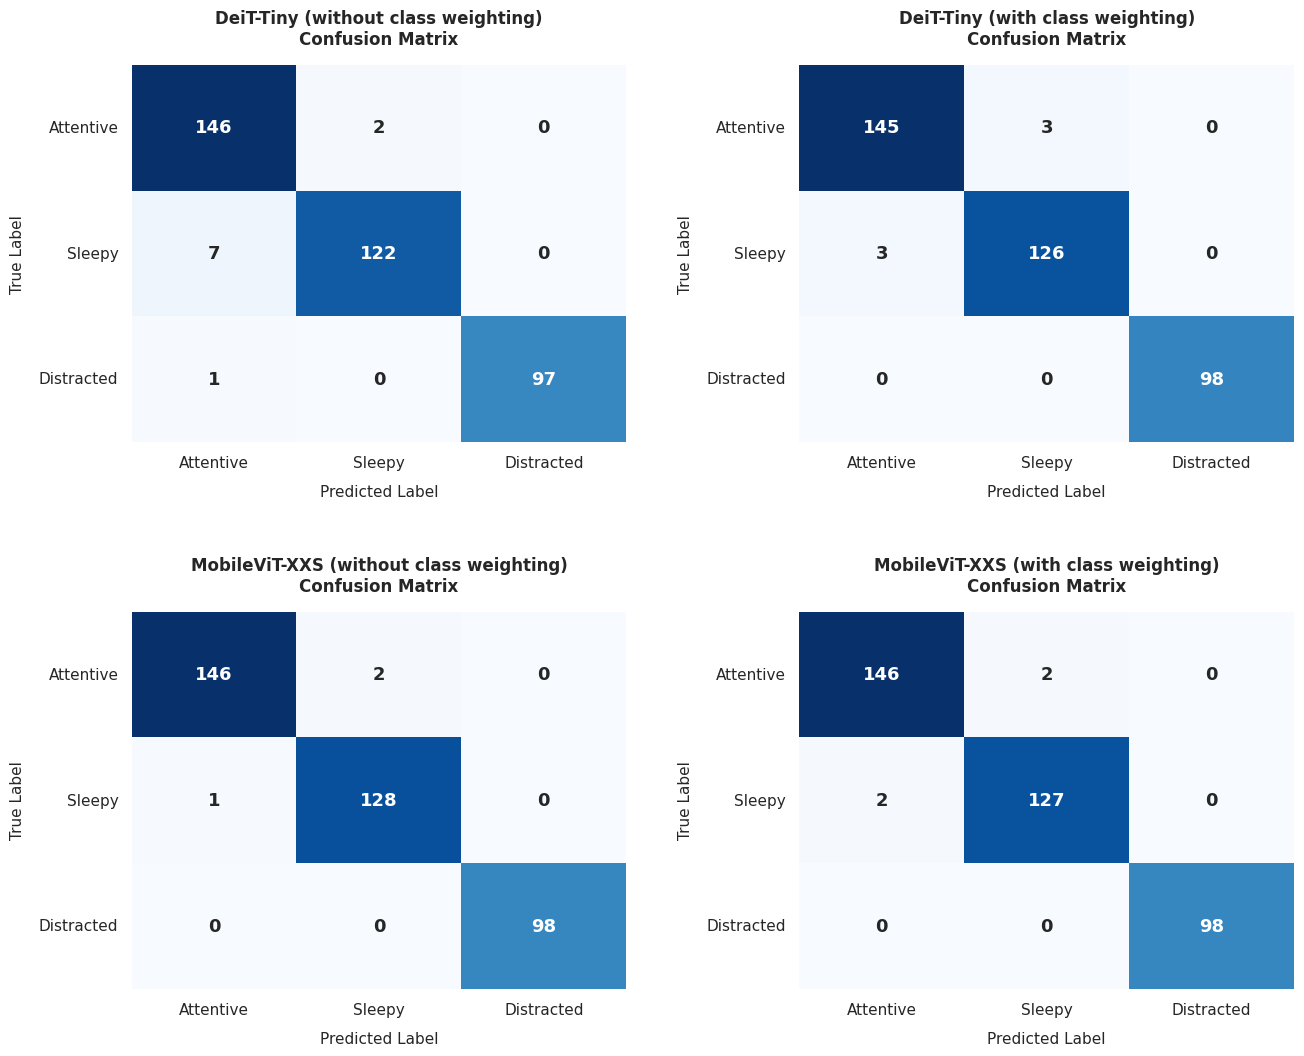

In [5]:
import os
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
import timm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TEST_DIR = '/content/working/splitted_dataset/test'
NUM_CLASSES = 3
CUSTOM_CLASS_TO_IDX = {'Attentive': 0, 'Sleepy': 1, 'Distracted': 2}
class_names = ['Attentive', 'Sleepy', 'Distracted']

# =====================================================================
# Helper: build test loader for a given image size
# =====================================================================
def get_test_loader(img_size):
    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    ds = datasets.ImageFolder(root=TEST_DIR, transform=tfm)
    ds.class_to_idx = CUSTOM_CLASS_TO_IDX
    ds.samples = [(p, CUSTOM_CLASS_TO_IDX[Path(p).parent.name]) for p, _ in ds.samples]
    return DataLoader(ds, batch_size=1, shuffle=False, num_workers=2)

test_loader_224 = get_test_loader(224)
test_loader_256 = get_test_loader(256)
print(f'Test samples: {len(test_loader_224.dataset)}')

# =====================================================================
# Model rebuild functions (must match training head structure)
# =====================================================================
def rebuild_deit(weights_path):
    m = timm.create_model('deit_tiny_patch16_224', pretrained=False, num_classes=0)
    m.head = nn.Sequential(
        nn.Linear(m.num_features, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, NUM_CLASSES)
    )
    m.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    return m

def rebuild_mobilevit(weights_path):
    m = timm.create_model('mobilevit_xxs', pretrained=False, num_classes=0)
    m.head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(m.num_features, NUM_CLASSES)
    )
    m.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    return m

# =====================================================================
# Evaluation engine (latency profiled at batch_size=1)
# =====================================================================
def evaluate_model(model_fn, weights_path, model_name, test_loader):
    print(f'\nEvaluating {model_name}...')
    model = model_fn(weights_path)
    file_size_mb = os.path.getsize(weights_path) / (1024 * 1024)
    model = model.to(DEVICE)
    model.eval()
    all_preds, all_targets, inference_times = [], [], []
    if DEVICE.type == 'cuda':
        dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
        for _ in range(10): _ = model(dummy)
        torch.cuda.synchronize()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            if DEVICE.type == 'cuda': torch.cuda.synchronize()
            t0 = time.perf_counter()
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            if DEVICE.type == 'cuda': torch.cuda.synchronize()
            inference_times.append((time.perf_counter() - t0) * 1000)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.numpy())
    all_targets = np.array(all_targets)
    all_preds   = np.array(all_preds)
    avg_latency = np.mean(inference_times)
    fps = 1000 / avg_latency
    accuracy = (all_targets == all_preds).mean() * 100
    print(f'\n=== {model_name} Performance Report ===')
    print(classification_report(all_targets, all_preds, target_names=class_names))
    cm = confusion_matrix(all_targets, all_preds)
    return {'name': model_name, 'size': file_size_mb, 'latency': avg_latency,
            'fps': fps, 'accuracy': accuracy, 'cm': cm,
            'preds': all_preds, 'targets': all_targets}

deit_wo  = evaluate_model(rebuild_deit,      '/content/drive/MyDrive/Transformer/models/best_deit_tiny_without.pth',    'DeiT-Tiny (without class weighting)',    test_loader_224)
deit_w   = evaluate_model(rebuild_deit,      '/content/drive/MyDrive/Transformer/models/best_deit_tiny_with.pth',       'DeiT-Tiny (with class weighting)',       test_loader_224)
mvit_wo  = evaluate_model(rebuild_mobilevit, '/content/drive/MyDrive/Transformer/models/best_mobilevit_xxs_without.pth','MobileViT-XXS (without class weighting)',test_loader_256)
mvit_w   = evaluate_model(rebuild_mobilevit, '/content/drive/MyDrive/Transformer/models/best_mobilevit_xxs_with.pth',   'MobileViT-XXS (with class weighting)',   test_loader_256)

# =====================================================================
# Comparison Table
# =====================================================================
print('\n' + '='*115)
print('FINAL TRANSFORMER ACCURACY & HARDWARE COMPARISON')
print('='*115)
print(f"| {'Model Name':<55} | {'Size (MB)':<10} | {'Latency (ms)':<12} | {'Throughput (FPS)':<16} | {'Test Acc (%)':<12} |")
print(f"|:{'-'*55}-|:{'-'*10}-|:{'-'*12}-|:{'-'*16}-|:{'-'*12}-|")
for res in [deit_wo, deit_w, mvit_wo, mvit_w]:
    print(f"| {res['name']:<55} | {res['size']:<10.2f} | {res['latency']:<12.2f} | {res['fps']:<16.1f} | {res['accuracy']:<12.2f} |")

# =====================================================================
# Confusion Matrices
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes_flat = axes.flatten()
for idx, res in enumerate([deit_wo, deit_w, mvit_wo, mvit_w]):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                xticklabels=class_names, yticklabels=class_names,
                cbar=False, annot_kws={'size': 13, 'weight': 'bold'})
    axes_flat[idx].set_title(f"{res['name']}\nConfusion Matrix", fontsize=12, fontweight='bold', pad=15)
    axes_flat[idx].set_ylabel('True Label', fontsize=11, labelpad=10)
    axes_flat[idx].set_xlabel('Predicted Label', fontsize=11, labelpad=10)
    axes_flat[idx].set_xticklabels(class_names, rotation=0)
    axes_flat[idx].set_yticklabels(class_names, rotation=0)
plt.subplots_adjust(wspace=0.35, hspace=0.45)
plt.show()

# Reference Image — 4-Model Comparative Dashboard

Loading all 4 transformer models...
All 4 models loaded!


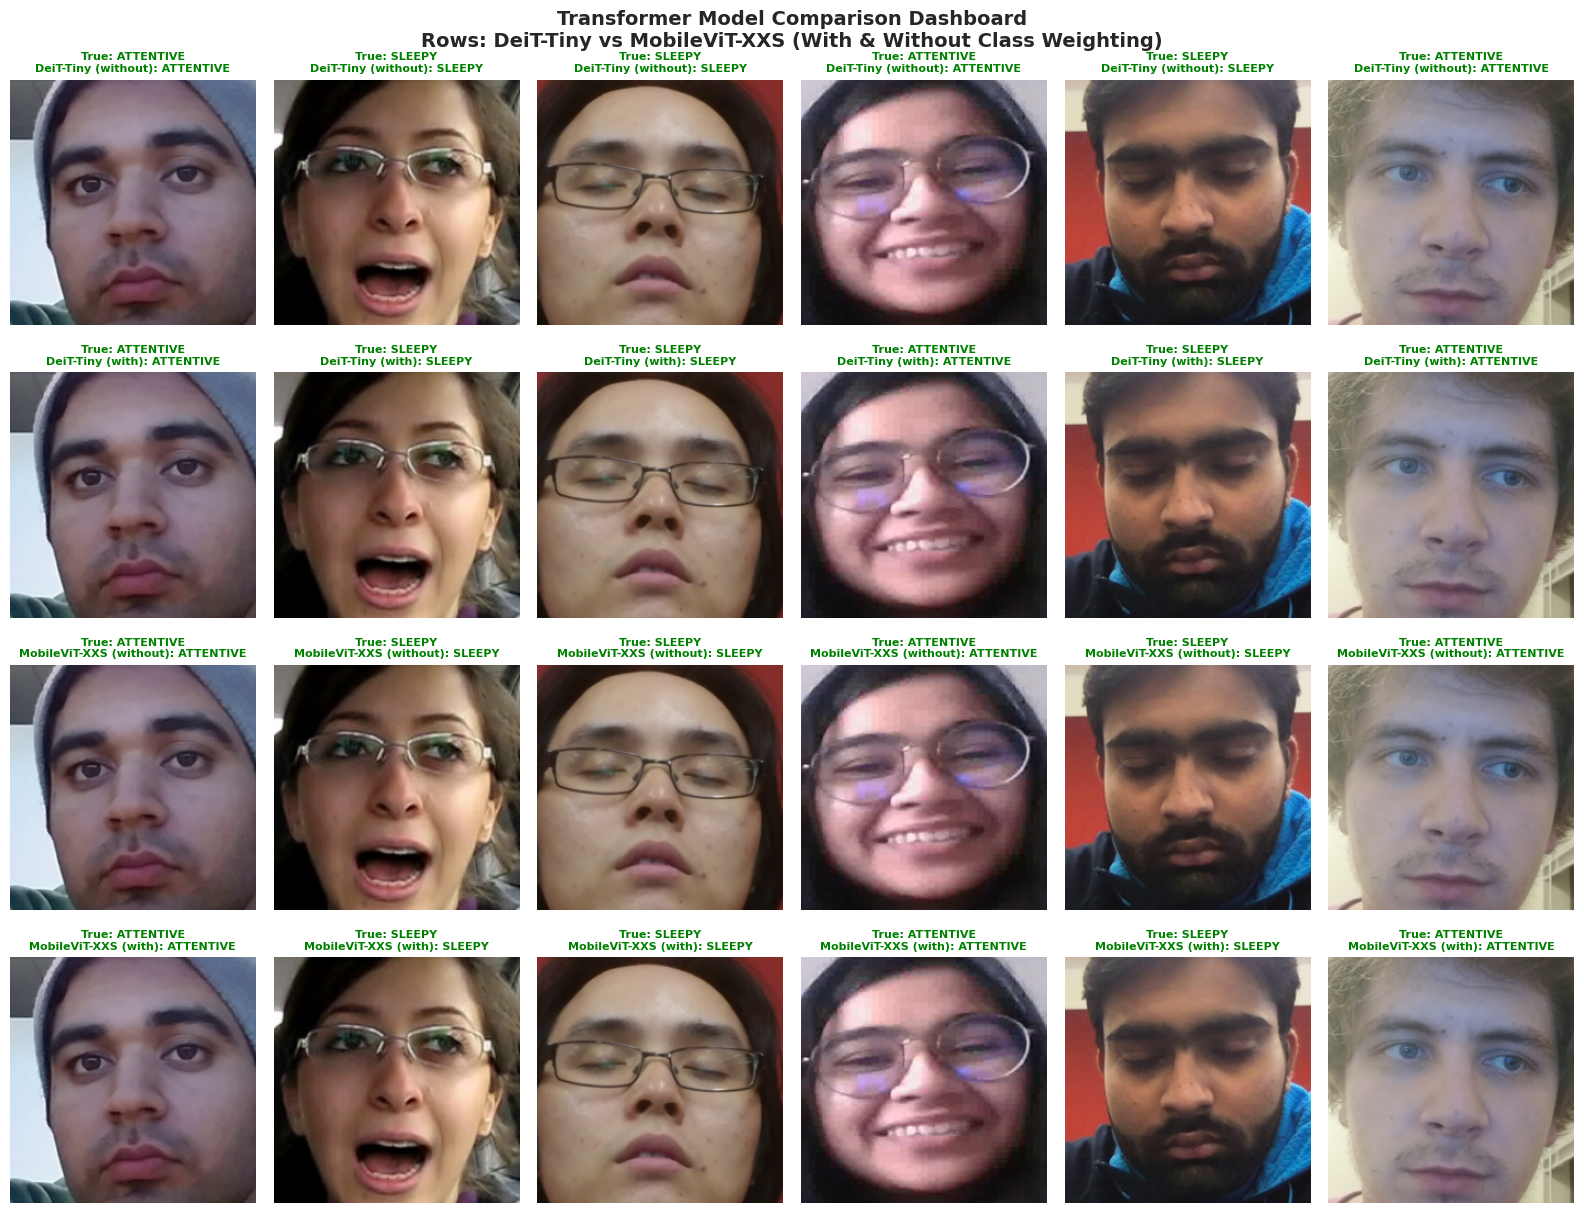

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path
import timm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TEST_DIR = '/content/working/splitted_dataset/test'
NUM_CLASSES = 3
CUSTOM_CLASS_TO_IDX = {'Attentive': 0, 'Sleepy': 1, 'Distracted': 2}
class_names = ['ATTENTIVE', 'SLEEPY', 'DISTRACTED']

# Load raw images (no normalisation) for display
raw_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=raw_transform)
test_dataset.class_to_idx = CUSTOM_CLASS_TO_IDX
test_dataset.samples = [(p, CUSTOM_CLASS_TO_IDX[Path(p).parent.name]) for p, _ in test_dataset.samples]
viz_loader = DataLoader(test_dataset, batch_size=6, shuffle=True)

norm_224 = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
norm_256 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def build_deit(weights_path):
    m = timm.create_model('deit_tiny_patch16_224', pretrained=False, num_classes=0)
    m.head = nn.Sequential(
        nn.Linear(m.num_features, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, NUM_CLASSES)
    )
    m.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    return m.to(DEVICE).eval()

def build_mobilevit(weights_path):
    m = timm.create_model('mobilevit_xxs', pretrained=False, num_classes=0)
    m.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(m.num_features, NUM_CLASSES)
        )
    m.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    return m.to(DEVICE).eval()

print('Loading all 4 transformer models...')
deit_wo  = build_deit('/content/drive/MyDrive/Transformer/models/best_deit_tiny_without.pth')
deit_w   = build_deit('/content/drive/MyDrive/Transformer/models/best_deit_tiny_with.pth')
mvit_wo  = build_mobilevit('/content/drive/MyDrive/Transformer/models/best_mobilevit_xxs_without.pth')
mvit_w   = build_mobilevit('/content/drive/MyDrive/Transformer/models/best_mobilevit_xxs_with.pth')
print('All 4 models loaded!')

images, labels = next(iter(viz_loader))
inp_224 = torch.stack([norm_224(img) for img in images]).to(DEVICE)
inp_256 = torch.stack([norm_256(img) for img in images]).to(DEVICE)

with torch.no_grad():
    _, p_deit_wo  = torch.max(deit_wo(inp_224),  1)
    _, p_deit_w   = torch.max(deit_w(inp_224),   1)
    _, p_mvit_wo  = torch.max(mvit_wo(inp_256),  1)
    _, p_mvit_w   = torch.max(mvit_w(inp_256),   1)

preds = {
    'DeiT-Tiny (without)':     p_deit_wo.cpu().numpy(),
    'DeiT-Tiny (with)':        p_deit_w.cpu().numpy(),
    'MobileViT-XXS (without)': p_mvit_wo.cpu().numpy(),
    'MobileViT-XXS (with)':    p_mvit_w.cpu().numpy(),
}
labels_np = labels.numpy()

fig, axes = plt.subplots(4, 6, figsize=(16, 12))
row_configs = list(preds.items())
for i in range(6):
    np_img = images[i].permute(1, 2, 0).numpy()
    np_img = np.clip(np_img, 0, 1)
    true_cls = class_names[labels_np[i]]
    for row_idx, (label_prefix, pred_arr) in enumerate(row_configs):
        pred_cls = class_names[pred_arr[i]]
        color = 'green' if pred_cls == true_cls else 'red'
        ax = axes[row_idx, i]
        ax.imshow(np_img)
        ax.axis('off')
        ax.set_title(f'True: {true_cls}\n{label_prefix}: {pred_cls}',
                     color=color, fontsize=8, fontweight='bold')

plt.tight_layout()
fig.suptitle('Transformer Model Comparison Dashboard\nRows: DeiT-Tiny vs MobileViT-XXS (With & Without Class Weighting)',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()